<a href="https://colab.research.google.com/github/Vanshu2374/ML-projects/blob/main/project6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6) Covid-19 Project

                                                   ID        Accession  \
0   hCoV-19/Colombia/AMA-INS-LET-2-013/2021|EPI_IS...  EPI_ISL_1820959   
1        hCoV-19/Colombia/ANT-CWOHC-VG-SEC00108D/2021  EPI_ISL_1824702   
2        hCoV-19/Colombia/ANT-CWOHC-VG-SEC00109E/2021  EPI_ISL_1824703   
3        hCoV-19/Colombia/ANT-CWOHC-VG-SEC00167K/2021  EPI_ISL_1824706   
4        hCoV-19/Colombia/ANT-CWOHC-VG-SEC00189G/2021  EPI_ISL_1824711   
..                                                ...              ...   
84  hCoV-19/USA/MI-UM-10039251404/2021|EPI_ISL_175...  EPI_ISL_1753673   
85  hCoV-19/USA/NJ-CDC-ASC210006835/2021|EPI_ISL_1...  EPI_ISL_1562674   
86  hCoV-19/USA/NY-PRL-2021_03_24_00P15/2021|EPI_I...  EPI_ISL_1385573   
87  hCoV-19/USA/NY-PRL-2021_0405_00N23/2021|EPI_IS...  EPI_ISL_1542954   
88  hCoV-19/USA/NY-PRL-2021_0409_00G23/2021|EPI_IS...  EPI_ISL_1543900   

   Collection_date  Lineage Clade  LocationCountry   Gender      Age   Status  \
0       12/03/2021  B.1.621   

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy score: 0.85
F1 score: 0.8421052631578947
Recall score: 0.8
Precision score: 0.8888888888888888
Congrats! Prediction Gender is the Female!
Prediction Model Accuracy Score: 0.9652777777777778 


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:568: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


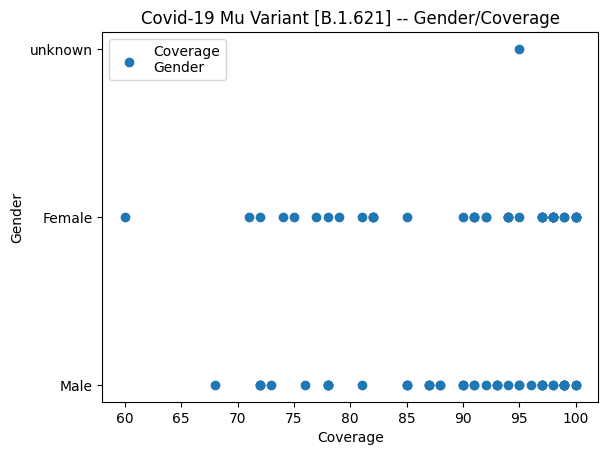

In [2]:
#libraries of the loading
from sklearn.ensemble import *
from sklearn.model_selection import *
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import *

#datasets loading...
mu_variant_data = pd.read_csv('mu-variant-data.csv')
print(mu_variant_data)
#change function..
def number_gender_change(x):
    if x == 'Male':
        return 0
    elif x == 'Female':
        return 1
    else:
        return 2

#change of the str to int.
mu_variant_data['Gender_Change'] = mu_variant_data['Gender'].apply(number_gender_change)

#creating of fetures
coverage_X = mu_variant_data.loc[:,['S:N501Y','S:E484K','S:R346K','S:P681H','Coverage']].values

#creating of class,target or label :)
gender_y = mu_variant_data.loc[:,['Gender_Change']].values

#fetaures print
#print(gender_y)

#try :)

#                                 *******CLASSIFICATION IS THE MU VARIANT*******
# we create the Train and Test datasets.. (parameters of the suitable)
coverage_X_train, coverage_X_test, gender_y_train, gender_y_test = train_test_split(coverage_X,
                                                                                    gender_y,
                                                                                    test_size=0.22,
                                                                                    stratify=None,
                                                                                    shuffle=True,
                                                                                    random_state=64)

# we create of the our model 8 Classifier)
model_mu_variant = BaggingClassifier(
                                     random_state=46,
                                     n_estimators=2,
                                     bootstrap=True,
                                     max_features=1.0,
                                     n_jobs=-1,
                                     warm_start=False)

# model is fitting with Train datasets.
model_mu_variant.fit(coverage_X_train, gender_y_train)

# Creating the Prediction equation
prediction = model_mu_variant.predict(coverage_X_test)

# Creating of Accuracy score, F1 Score, Recall Score, Precision Score and Confusion Matrix :)
print(f"Accuracy score: {accuracy_score(gender_y_test, prediction)}")
print(f"F1 score: {f1_score(gender_y_test, prediction)}")
print(f"Recall score: {recall_score(gender_y_test, prediction)}")
print(f"Precision score: {precision_score(gender_y_test, prediction)}")
# print(f"Confusion Matrix: {confusion_matrix(gender_y_test, prediction)}")

    #                                 *******PREDICTION IS THE MU VARIANT*******
X_train, X_test, y_train, y_test = train_test_split(coverage_X,
                                                    gender_y,
                                                    test_size=0.05,
                                                    stratify=None,
                                                    shuffle=True,
                                                    random_state=265)

# creating of our predicting model
model_mu_variant_predict = BaggingRegressor(
                                            random_state=149,
                                            n_estimators=1,
                                            bootstrap=True,
                                            max_features=1.0,
                                            n_jobs=-1,
                                            warm_start=True, bootstrap_features=True)

# our model is fitting..
model_mu_variant_predict.fit(X_train, y_train)

# our model is predicting..
a = model_mu_variant_predict.predict(X_test)

predi = model_mu_variant_predict.predict([[1, 1, 0, 1, 2]])

for i in predi:
    if i == [1.]:
        print("Congrats! Prediction Gender is the Female!")
    elif i == [0.]:
        print("Congrats! Prediction Gender is the Male!")
    else:
        print("Sorry! Prediction Gender is the Unknown!")

# our prediction software is the accuracy score :)
print(f"Prediction Model Accuracy Score: {r2_score(y_test, a)} ")


feature_names = mu_variant_data.loc[:,['S:N501Y','S:E484K','S:R346K','S:P681H','Coverage']].columns

from sklearn.tree import *

def save_decision_trees_as_dot(model_mu_variant, iteration, feature_name):
    #file_name = open("emirhan_mu_variant_classification" + str(iteration) + ".dot", 'w')
    dot_data = export_graphviz(
        model_mu_variant,
        #out_file=file_name,
        feature_names=feature_name,
        class_names=['Male','Female','Unknown'],
        rounded=True,
        proportion=False,
        precision=2,
        filled=True, )
    #file_name.close()
    print("Classification {} saved as dot file".format(iteration + 1))


# Save of the .dot loop..
#for i in range(len(model_mu_variant.estimators_)):
    #save_decision_trees_as_dot(model_mu_variant.estimators_[i], i, feature_names)
    #print(i)


plt.scatter(mu_variant_data['Coverage'],mu_variant_data['Gender'])
plt.legend(["Coverage\nGender"])
plt.xlabel("Coverage")
plt.ylabel("Gender")
plt.title("Covid-19 Mu Variant [B.1.621] -- Gender/Coverage")
plt.show()